In [ ]:
import glob
import os
import sqlite3
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import PartialDependenceDisplay
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from xgboost import XGBClassifier

In [3]:
CSV_FOLDER = "./features"
csv_files = glob.glob(os.path.join(CSV_FOLDER, "*.csv"))
conn = sqlite3.connect(":memory:")

for path in csv_files:
    file_name = os.path.splitext(os.path.basename(path))[0]
    df = pd.read_csv(path)[["NPA", "2023"]].rename(columns={"2023": file_name})
    df.to_sql(file_name, conn, index=False, if_exists="replace")
 
table_names = [os.path.splitext(os.path.basename(p))[0] for p in csv_files]
query = f'SELECT * FROM "{table_names[0]}"'

for table in table_names[1:]:
    query = f"""
    SELECT * FROM ({query.strip()})
    LEFT JOIN "{table}" USING(NPA)
    """
 
merged = pd.read_sql(query, conn)
conn.close()

merged.to_csv("merged_output.csv", index=False)

In [4]:
df = pd.read_csv("merged_output.csv").drop(columns=["NPA"])
 
def clean_col(series):
    s = series.replace("--", np.nan)
    s = s.astype(str).str.replace(r"[$,%]", "", regex=True).str.replace(",", "")
    return pd.to_numeric(s, errors="coerce")
 
for col in df.columns:
    df[col] = clean_col(df[col])
 
target_cols = ["Test Proficiency - Elementary School", "Test Proficiency - Middle School", "Test Proficiency - High School"]
df = df.dropna(subset=target_cols, how="all")
df["Test Proficiency - K12"] = df[target_cols].mean(axis=1)
 
print(df["Test Proficiency - K12"].describe().round(2))

count    455.00
mean      47.22
std       22.00
min        7.73
25%       30.38
50%       40.20
75%       65.92
max       95.33
Name: Test Proficiency - K12, dtype: float64


In [5]:
bins = [0, 25, 50, 75, 100]
labels = ["At Risk", "Low", "Moderate", "High"]
df["Proficiency Level"] = pd.cut(
    df["Test Proficiency - K12"],
    bins=bins,
    labels=labels,
    include_lowest=True,
)
print(df["Proficiency Level"].value_counts())

Proficiency Level
Low         214
Moderate     94
High         79
At Risk      68
Name: count, dtype: int64


In [6]:
feature_cols = [
    col for col in df.columns
    if col not in ["Test Proficiency - K12", "Proficiency Level"] + target_cols
]
model_df = df[feature_cols + ["Proficiency Level"]].dropna(subset=["Proficiency Level"])
 
X = model_df[feature_cols]
y = model_df["Proficiency Level"].cat.codes
class_names = list(model_df["Proficiency Level"].cat.categories)
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [7]:
numeric_features = X.columns.tolist()
 
scaled_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numeric_features)
    ],
    remainder="drop",
)
 
tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
        ]), numeric_features)
    ],
    remainder="drop",
)

In [8]:
pipelines = {
    "LDA": Pipeline([
        ("preprocessor", scaled_preprocessor),
        ("model", LinearDiscriminantAnalysis()),
    ]),
    "QDA": Pipeline([
        ("preprocessor", scaled_preprocessor),
        ("model", QuadraticDiscriminantAnalysis()),
    ]),
    "SVM": Pipeline([
        ("preprocessor", scaled_preprocessor),
        ("model", SVC(kernel="rbf", class_weight="balanced", random_state=42)),
    ]),
    "Random Forest": Pipeline([
        ("preprocessor", tree_preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=300, random_state=42, class_weight="balanced"
        )),
    ]),
    "XGBoost": Pipeline([
        ("preprocessor", tree_preprocessor),
        ("model", XGBClassifier(
            objective="multi:softprob",
            num_class=4,
            eval_metric="mlogloss",
            n_estimators=300,
            learning_rate=0.1,
            max_depth=4,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=42,
        )),
    ]),
}

In [9]:
results = []
for name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "Macro F1": f1_score(y_test, y_pred, average="macro"),
    })
    print(f"\n{name}")
    print(classification_report(y_test, y_pred, target_names=class_names))
 
results_df = pd.DataFrame(results).sort_values("Macro F1", ascending=False)
display(results_df)


LDA
              precision    recall  f1-score   support

     At Risk       0.53      0.62      0.57        13
         Low       0.81      0.81      0.81        43
    Moderate       0.67      0.63      0.65        19
        High       0.73      0.69      0.71        16

    accuracy                           0.73        91
   macro avg       0.69      0.69      0.69        91
weighted avg       0.73      0.73      0.73        91


QDA
              precision    recall  f1-score   support

     At Risk       0.41      0.54      0.47        13
         Low       0.76      0.67      0.72        43
    Moderate       0.67      0.63      0.65        19
        High       0.78      0.88      0.82        16

    accuracy                           0.68        91
   macro avg       0.65      0.68      0.66        91
weighted avg       0.70      0.68      0.69        91


SVM
              precision    recall  f1-score   support

     At Risk       0.42      0.62      0.50        13
      

,Model,Accuracy,Balanced Accuracy,Macro F1
4,XGBoost,0.780220,0.740805,0.750756
3,Random Forest,0.780220,0.722379,0.738684
0,LDA,0.725275,0.687104,0.685927
1,QDA,0.681319,0.679865,0.663724
2,SVM,0.637363,0.647937,0.617476


In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []
cv_per_class_f1 = []
 
for name, pipeline in pipelines.items():
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "Accuracy": "accuracy",
            "Balanced Accuracy": "balanced_accuracy",
            "Macro F1": "f1_macro",
        },
        n_jobs=-1,
    )
    y_cv_pred = cross_val_predict(pipeline, X_train, y_train, cv=cv, n_jobs=-1)
    report = classification_report(
        y_train,
        y_cv_pred,
        target_names=class_names,
        output_dict=True,
        zero_division=0,
    )
    cv_results.append({
        "Model": name,
        "CV Accuracy Mean": scores["test_Accuracy"].mean(),
        "CV Accuracy Std": scores["test_Accuracy"].std(),
        "CV Balanced Accuracy Mean": scores["test_Balanced Accuracy"].mean(),
        "CV Balanced Accuracy Std": scores["test_Balanced Accuracy"].std(),
        "CV Macro F1 Mean": scores["test_Macro F1"].mean(),
        "CV Macro F1 Std": scores["test_Macro F1"].std(),
    })
    cv_per_class_f1.append({
        "Model": name,
        **{f"{cls} F1": report[cls]["f1-score"] for cls in class_names},
    })
 
cv_results_df = pd.DataFrame(cv_results).sort_values("CV Macro F1 Mean", ascending=False)
cv_per_class_f1_df = pd.DataFrame(cv_per_class_f1).set_index("Model")
display(cv_results_df)
display(cv_per_class_f1_df)

,Model,CV Accuracy Mean,CV Accuracy Std,CV Balanced Accuracy Mean,CV Balanced Accuracy Std,CV Macro F1 Mean,CV Macro F1 Std
4,XGBoost,0.697907,0.035969,0.660332,0.031082,0.661464,0.033389
3,Random Forest,0.700571,0.052842,0.619659,0.051937,0.631976,0.058611
0,LDA,0.642808,0.027982,0.579780,0.029745,0.586216,0.038523
2,SVM,0.579414,0.049006,0.582787,0.056503,0.553886,0.060270
1,QDA,0.587823,0.024456,0.523966,0.044650,0.511760,0.043972


,At Risk F1,Low F1,Moderate F1,High F1
Model,,,,
LDA,0.524272,0.764873,0.503145,0.566372
QDA,0.420000,0.711111,0.356589,0.604317
SVM,0.533333,0.668919,0.479532,0.555556
Random Forest,0.390244,0.781250,0.582090,0.781250
XGBoost,0.490196,0.755682,0.606897,0.806202


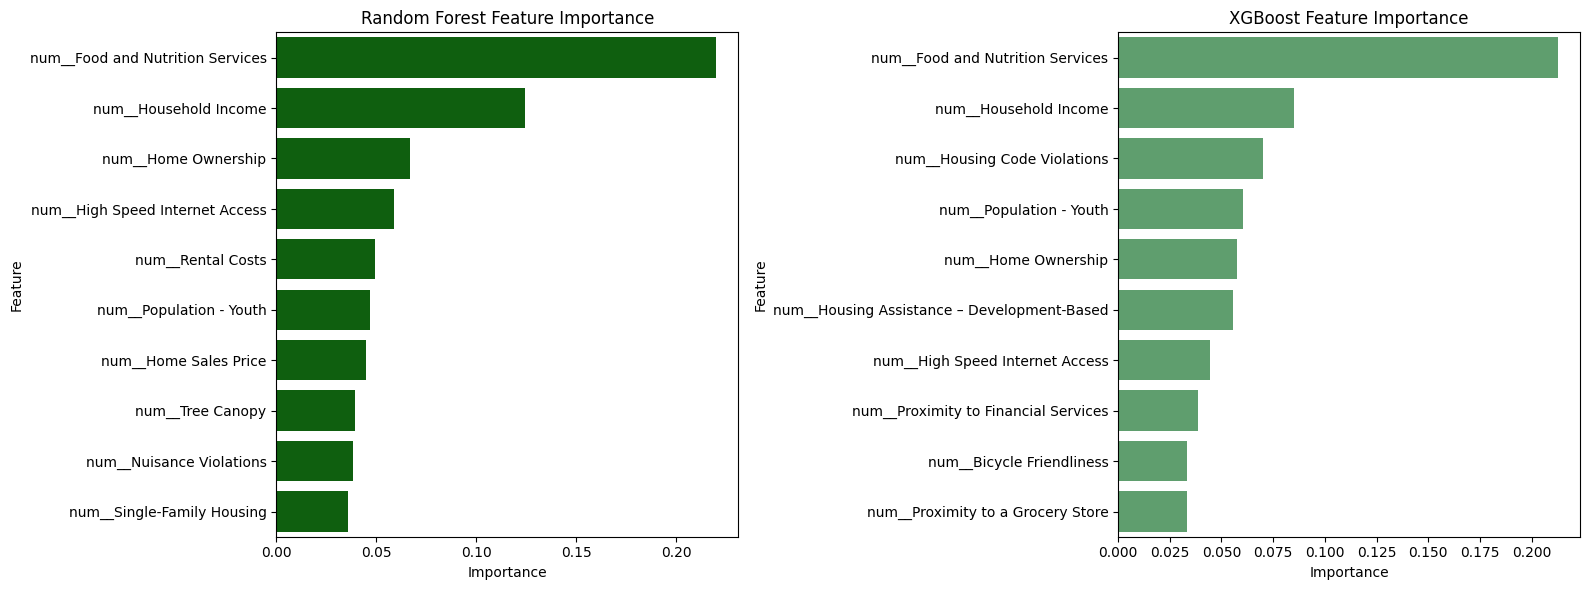

In [11]:
def get_feature_importance(model_name):
    pipeline = pipelines[model_name]
    feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()
    importances  = pipeline.named_steps["model"].feature_importances_
    return pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances,
    }).sort_values("Importance", ascending=False)
 
rf_importance  = get_feature_importance("Random Forest")
xgb_importance = get_feature_importance("XGBoost")
 
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)
sns.barplot(data=rf_importance.head(10), x="Importance", y="Feature", ax=axes[0], color="#026C02")
sns.barplot(data=xgb_importance.head(10), x="Importance", y="Feature", ax=axes[1], color="#55A868")
axes[0].set_title("Random Forest Feature Importance")
axes[1].set_title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()

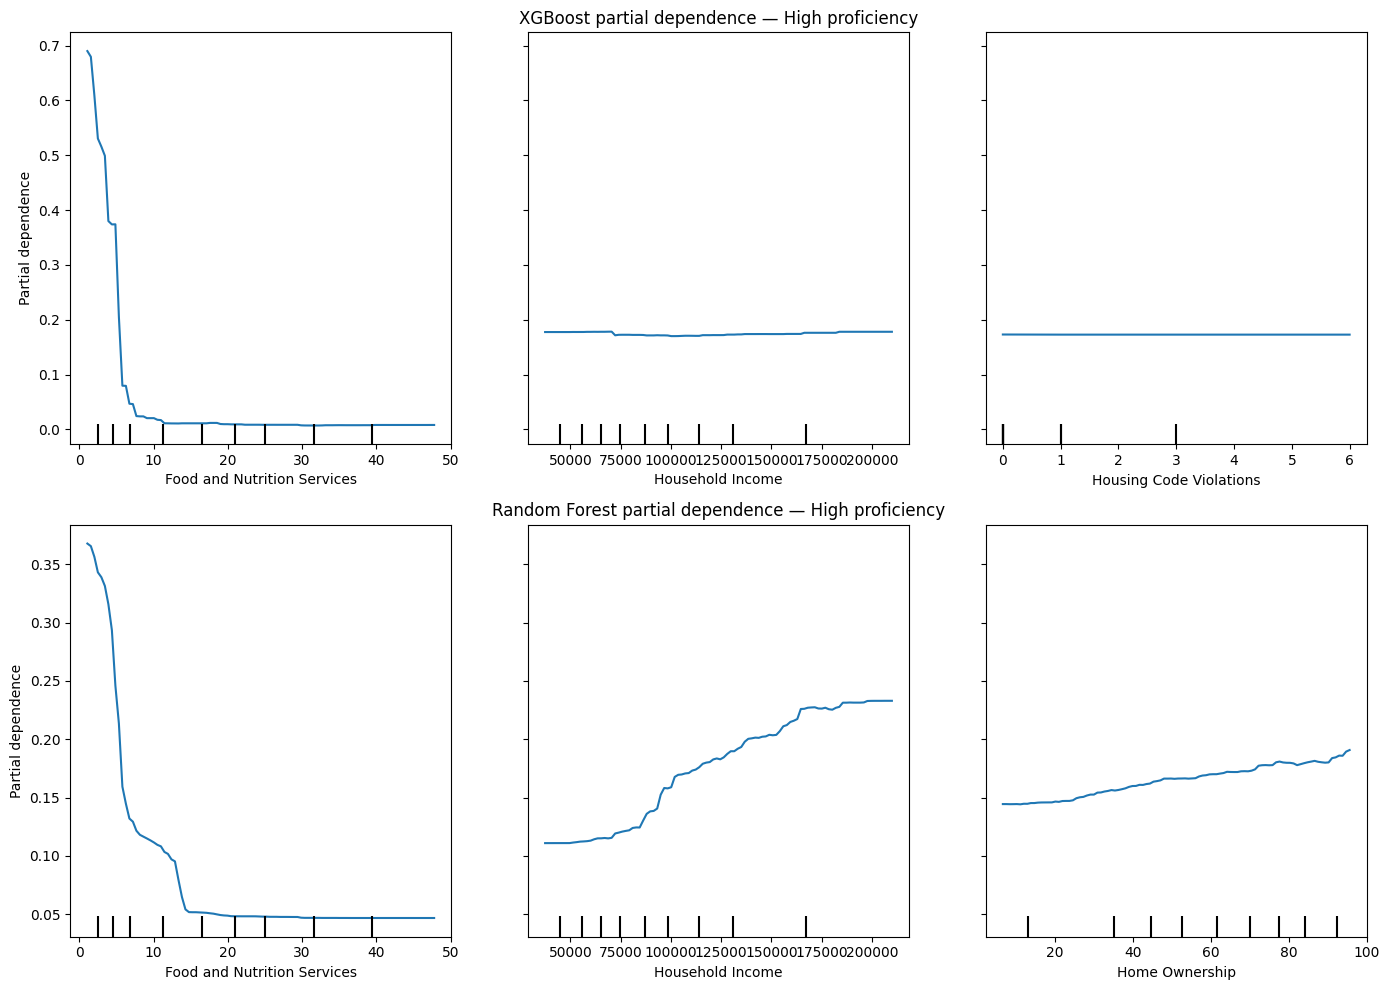

In [12]:
rf_top = [f.replace("num__", "") for f in rf_importance["Feature"].head(3)]
xgb_top = [f.replace("num__", "") for f in xgb_importance["Feature"].head(3)]
 
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
PartialDependenceDisplay.from_estimator(
    pipelines["XGBoost"], X_train, features=xgb_top, target=3, kind="average", ax=axes[0]
)
axes[0].set_title("XGBoost partial dependence — High proficiency")
PartialDependenceDisplay.from_estimator(
    pipelines["Random Forest"], X_train, features=rf_top, target=3, kind="average", ax=axes[1]
)
axes[1].set_title("Random Forest partial dependence — High proficiency")
plt.tight_layout()
plt.show()

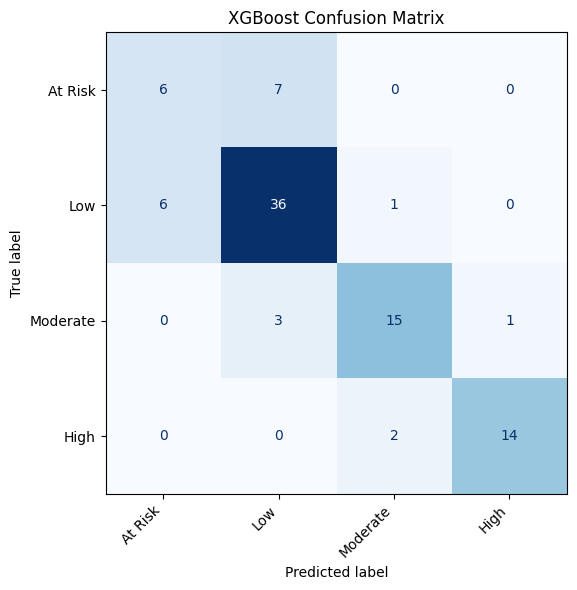

In [15]:
xgb_model = pipelines["XGBoost"]
y_pred_xgb = xgb_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
ax.set_title("XGBoost Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()